In [43]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from src.preprocessing import leave_k_last

In [44]:
ratings = pd.read_csv("../data/ml-latest-small/ratings.csv")
links = pd.read_csv("../data/ml-latest-small/links.csv")
movies = pd.read_csv("../data/ml-latest-small/movies.csv")
tags = pd.read_csv("../data/ml-latest-small/tags.csv")

In [45]:
dataframes = {'ratings': ratings, 'links': links, 'movies': movies, 'tags': tags}

for name, df in dataframes.items():
    print(f"\n=== {name} {df.shape} ===")
    display(df.head())


=== ratings (100836, 4) ===


,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931



=== links (9742, 3) ===


,movieId,imdbId,tmdbId
0,1,114709,862.0
1,2,113497,8844.0
2,3,113228,15602.0
3,4,114885,31357.0
4,5,113041,11862.0



=== movies (9742, 3) ===


,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy



=== tags (3683, 4) ===


,userId,movieId,tag,timestamp
0,2,60756,funny,1445714994
1,2,60756,Highly quotable,1445714996
2,2,60756,will ferrell,1445714992
3,2,89774,Boxing story,1445715207
4,2,89774,MMA,1445715200


In [46]:
n_users = ratings['userId'].nunique()
n_movies = ratings['movieId'].nunique()
density = ratings.shape[0] / (n_users * n_movies)
print(f"Unique users: {n_users}")
print(f"Unique movies: {n_movies}")
print(f"Density of ratings matrix: {density:.3f}")

Unique users: 610
Unique movies: 9724
Density of ratings matrix: 0.017


In [47]:
print(ratings.info())
print("-"*10)
print(ratings.describe())

<class 'pandas.DataFrame'>
RangeIndex: 100836 entries, 0 to 100835
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   userId     100836 non-null  int64  
 1   movieId    100836 non-null  int64  
 2   rating     100836 non-null  float64
 3   timestamp  100836 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 3.1 MB
None
----------
              userId        movieId         rating     timestamp
count  100836.000000  100836.000000  100836.000000  1.008360e+05
mean      326.127564   19435.295718       3.501557  1.205946e+09
std       182.618491   35530.987199       1.042529  2.162610e+08
min         1.000000       1.000000       0.500000  8.281246e+08
25%       177.000000    1199.000000       3.000000  1.019124e+09
50%       325.000000    2991.000000       3.500000  1.186087e+09
75%       477.000000    8122.000000       4.000000  1.435994e+09
max       610.000000  193609.000000       5.000000  1.537799e+09


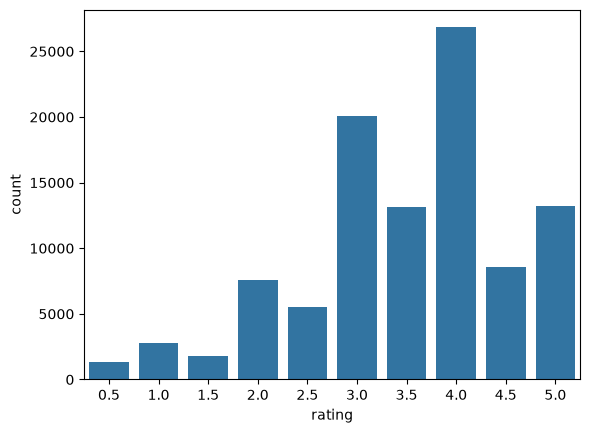

In [48]:
sns.countplot(data=ratings,x="rating")
plt.show()

In [49]:
diff_ids = set(movies["movieId"]) - set(ratings["movieId"])
print(f"Number of cold movies: {len(diff_ids)}")

Number of cold movies: 18


In [50]:
users_activity = ratings.groupby("userId").size()
movies_activity = ratings.groupby("movieId").size()
print(users_activity.describe())
print("-"*10)
print(movies_activity.describe())

count     610.000000
mean      165.304918
std       269.480584
min        20.000000
25%        35.000000
50%        70.500000
75%       168.000000
max      2698.000000
dtype: float64
----------
count    9724.000000
mean       10.369807
std        22.401005
min         1.000000
25%         1.000000
50%         3.000000
75%         9.000000
max       329.000000
dtype: float64


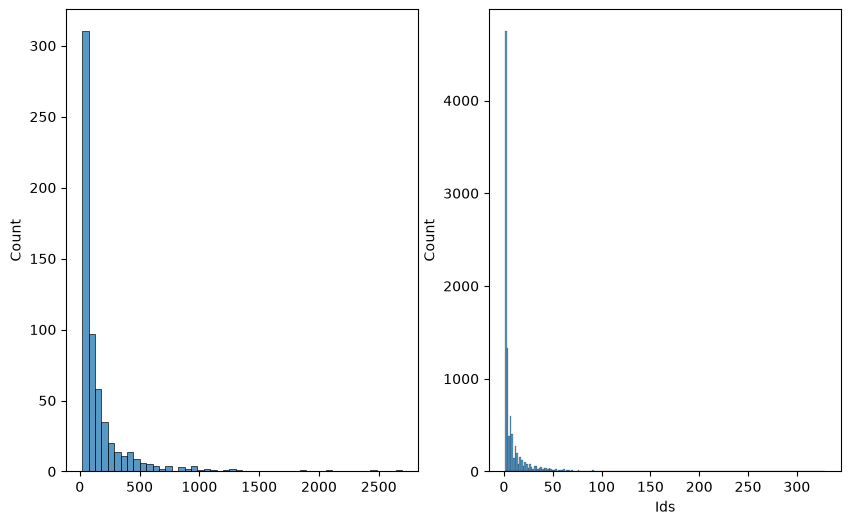

In [51]:
fig, axes = plt.subplots(1,2,figsize=(10,6))

sns.histplot(data=users_activity,ax=axes[0])
sns.histplot(data=movies_activity,ax=axes[1])
plt.xlabel("Ids")
plt.show()

### Splitting by leave-k-last

In [52]:
sorted_ratings = ratings.sort_values(
    by=["userId", "timestamp"], 
    ascending=[True, False]
).reset_index(drop=True)

k = 1

sorted_ratings["item_rank"] = sorted_ratings.groupby("userId").cumcount()

train = sorted_ratings[sorted_ratings["item_rank"] >= k].drop(columns=["item_rank"])
test = sorted_ratings[sorted_ratings["item_rank"] < k].drop(columns=["item_rank"])

print(f"Train size: {len(train)}, Test size: {len(test)}")

Train size: 100226, Test size: 610


In [53]:
train, test = leave_k_last(ratings, k=1)
assert(len(train) + len(test) == len(ratings))

In [54]:
output_dir = Path("../data/processed")
output_dir.mkdir(parents=True, exist_ok=True)

train.to_csv(output_dir / "train.csv", index=False)
test.to_csv(output_dir / "test.csv", index=False)